In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from collections import defaultdict
import matplotlib.ticker as ticker
import glob
import os
import pickle
import sys
import re
import ast
sys.path.append("/scratch/halmazan//WCTE/WCTECoincidence_Analysis/Complete_analysis")

from matplotlib import rcParams
rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [10, 8]
rcParams['font.size'] = 22

In [5]:
positions = ['Pos 1', 'Pos 2', 'Pos 3', 'Pos 5']
run = ['2385', '2386', '2387', '2389']

cap_mc = 67
cap_mc_err = 3

df_r = []

capture_time, capture_time_err = [], []
prompt_candidates, selected_events = [], []
prompt_candidates_err, selected_events_err = [], []
eff, eff_err = [], []
eff_proj, eff_proj_err = [], []
projected_selected, projected_selected_err = [], []
for i in range(0, len(run)): 
    df_r.append(pd.read_csv(f'/scratch/halmazan/WCTE/files/data/AmBeCandidates/selection_numbers_run_{run[i]}.csv'))
    capture_time.append(df_r[i][df_r[i].data_type == 'cand'].capture_time.values[0])
    capture_time_err.append(df_r[i][df_r[i].data_type == 'cand'].capture_time_err.values[0])
    prompt_candidates.append(df_r[i][df_r[i].data_type == 'cand'].prompt_candidates.values[0])
    selected_events.append(df_r[i][df_r[i].data_type == 'cand'].selected_events.values[0])
    eff.append(df_r[i][df_r[i].data_type == 'cand'].efficiency.values[0])
    prompt_candidates_err.append(np.sqrt(prompt_candidates[i]))
    selected_events_err.append(np.sqrt(selected_events[i]))
    projected_selected.append(prompt_candidates[i]*1.6)
    projected_selected_err.append(np.sqrt(projected_selected[i]))
    eff_proj.append(selected_events[i]*100/projected_selected[i])
    eff_proj_err.append(eff_proj[i] * np.sqrt((selected_events_err[i]/selected_events[i])**2 + (projected_selected_err[i]/projected_selected[i])**2))
    eff_err.append(eff[i] * np.sqrt((prompt_candidates_err[i]/prompt_candidates[i])**2 + (selected_events_err[i]/selected_events[i])**2))



#df_r = pd.concat(df_r, ignore_index=True)

In [6]:
df_r[0]

,data_type,time_windows,prompt_candidates,selected_events,efficiency,capture_time,capture_time_err
0,signal,75987.0,13162.000000,4347.000000,33.026896,NaN,NaN
1,bkg,157643.0,10590.000000,2767.000000,26.128423,NaN,NaN
2,cand,NaN,8057.413498,3013.252044,37.397262,67.307617,3.712821


In [7]:
capture_time, capture_time_err

([np.float64(67.30761699514646),
  np.float64(67.20534138579323),
  np.float64(58.623519038626974),
  np.float64(56.94055033373743)],
 [np.float64(3.712820603780468),
  np.float64(2.71803733381804),
  np.float64(1.7593430664267962),
  np.float64(1.4868501088545314)])

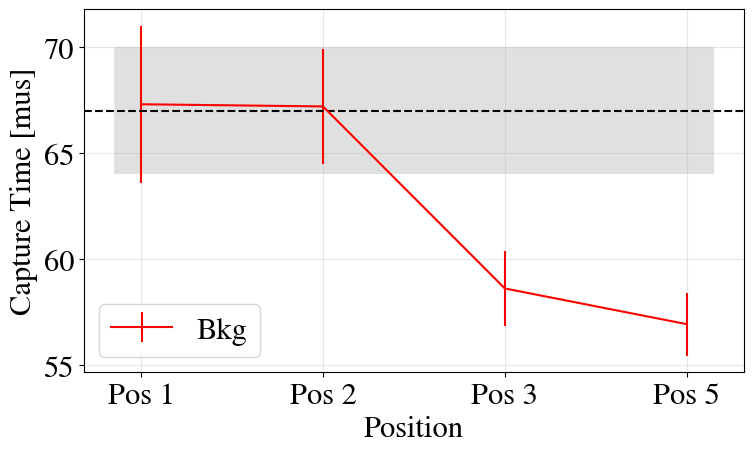

In [8]:
fig, ax = plt.subplots(figsize=(8,5))

# Data errorbars (use consistent color cycle for accessibility)
ax.errorbar(positions, capture_time, yerr=capture_time_err, fmt='r-',label="Bkg")
#ax.errorbar(positions, cap_acc, yerr=cap_acc_err, fmt='p--', label="Acc")
#ax.errorbar(positions, cap_acc2, yerr=cap_acc2_err,  fmt='g--', label="Acc 2")

# Horizontal line for MC central value
ax.axhline(cap_mc, color='k', linestyle='--', linewidth=1.5)

# Shaded band for MC uncertainty (drawn across full x-range)
xmin, xmax = ax.get_xlim()           # acquire axis limits after plotting
ax.fill_between([xmin, xmax],       # x-range
                cap_mc - cap_mc_err,
                cap_mc + cap_mc_err,
                color='k', alpha=0.12, linewidth=0)


handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles)

ax.set_xlabel("Position")
ax.set_ylabel("Capture Time [mus]")

ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

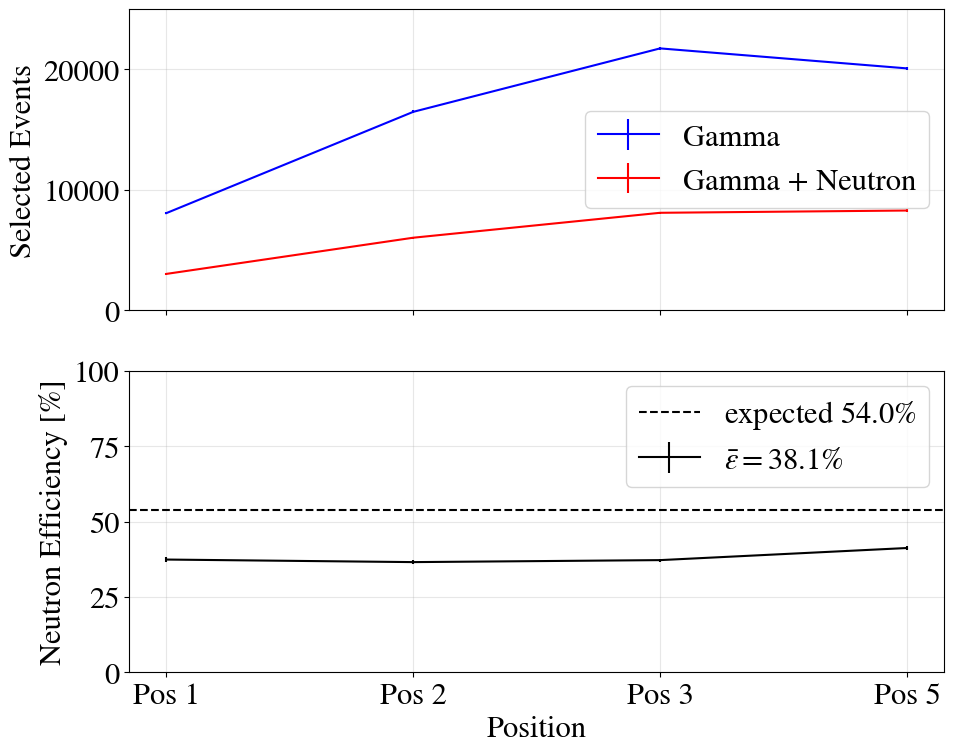

: 

In [13]:
# Create figure with two vertical subplots (share x)
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, sharex=True,
                                        gridspec_kw={'height_ratios': [1, 1]},
                                        figsize=(10, 8))

ax_top.errorbar(positions, prompt_candidates, yerr=prompt_candidates_err, fmt='b-', label="Gamma")
ax_top.errorbar(positions, selected_events, yerr=selected_events_err, fmt='r-', label="Gamma + Neutron")
#ax_top.errorbar(positions, cand, yerr=sig_err, fmt='g--', label="Candidates")
ax_top.set_ylim(0, 25000)
ax_top.set_ylabel("Selected Events")
ax_top.legend()
ax_top.grid(alpha=0.3)

eff_total_theo = (0.75*0.72)*100

ax_bottom.errorbar(positions, eff, yerr=eff_err, fmt='-', color='k', label = rf"$\bar{{\epsilon}} = {np.mean(eff):.1f}\%$")
ax_bottom.axhline(eff_total_theo, color='k', linestyle='--', linewidth=1.5, label=rf'expected ${(eff_total_theo):.1f}\%$')
ax_bottom.set_ylim(0, 100)
ax_bottom.set_xlabel("Position")
ax_bottom.set_ylabel("Neutron Efficiency [%]")
ax_bottom.legend()
ax_bottom.grid(alpha=0.3)
plt.tight_layout()
plt.show()

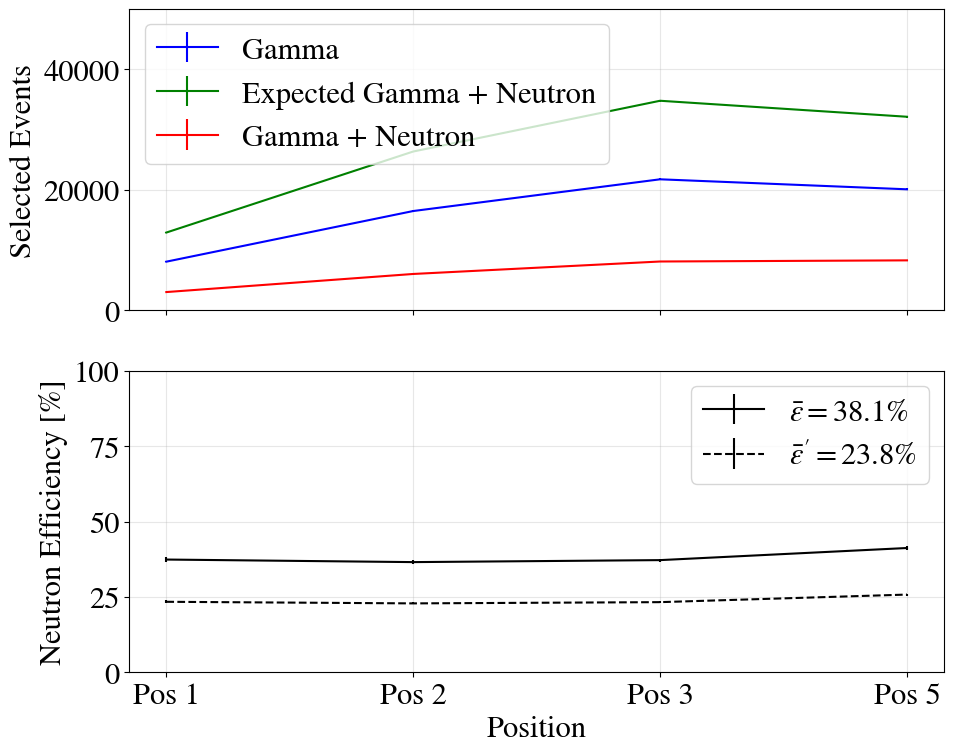

In [10]:
# Create figure with two vertical subplots (share x)
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, sharex=True,
                                        gridspec_kw={'height_ratios': [1, 1]},
                                        figsize=(10, 8))

ax_top.errorbar(positions, prompt_candidates, yerr=prompt_candidates_err, fmt='b-', label="Gamma")
ax_top.errorbar(positions, projected_selected, yerr=projected_selected_err, fmt='g-', label="Expected Gamma + Neutron")
ax_top.errorbar(positions, selected_events, yerr=selected_events_err, fmt='r-', label="Gamma + Neutron")
#ax_top.errorbar(positions, cand, yerr=sig_err, fmt='g--', label="Candidates")
ax_top.set_ylim(0, 50000)
ax_top.set_ylabel("Selected Events")
ax_top.legend()
ax_top.grid(alpha=0.3)


ax_bottom.errorbar(positions, eff, yerr=eff_err, fmt='-', color='k', label = rf"$\bar{{\epsilon}} = {np.mean(eff):.1f}\%$")
ax_bottom.errorbar(positions, eff_proj, yerr=eff_proj_err, fmt='--', color='k', label = rf"$\bar{{\epsilon}}' = {np.mean(eff_proj):.1f}\%$")
ax_bottom.set_ylim(0, 100)
ax_bottom.set_xlabel("Position")
ax_bottom.set_ylabel("Neutron Efficiency [%]")
ax_bottom.legend()
ax_bottom.grid(alpha=0.3)
plt.tight_layout()
plt.show()